1) Install and import libraries

What: Install CatBoost if necessary and import the Python libraries required throughout the notebook.

Why: Google Colab environments may not have the required CatBoost package available by default. The other libraries are used for data handling, model evaluation, cross-validation and visualisation.

How: Install CatBoost with pip, then import the required libraries.

In [ ]:
# Install CatBoost
!pip install catboost -q

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# CatBoost
from catboost import CatBoostClassifier

# Train/test split and cross-validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


2) Upload and load dataset

What: Upload final_processed_churn_data.csv to Colab and load it into a pandas DataFrame.

Why: The model needs the processed dataset as its modelling input.

How: Use Colab's file upload functionality and read the uploaded CSV.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

#df = pd.read_csv("/content/drive/MyDrive/AI&ML project/model 2/final_processed_churn_data.csv")
base_path = "/content/drive/MyDrive/AI&ML project/model 2/"
train_df = pd.read_csv(base_path + "final_train_processed.csv")
test_df = pd.read_csv(base_path + "final_test_processed.csv")

train_df.head()
test_df.head()

Mounted at /content/drive


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.196483,0,0.193211,1.394672,-1.341260,0.878882,0,0,0.615301,0,0,-0.034391,0.961455,-1.195658,-0.458065,0,1,0
1,1.130834,1,-1.182269,0.011320,0.353342,0.878882,0,1,-0.244237,1,0,-0.028813,0.474536,-0.288717,-0.063557,0,0,0
2,0.637989,0,-1.182269,0.702996,1.066331,-0.772148,1,1,-0.268687,1,0,-0.026335,1.276520,1.381400,-0.679976,1,0,0
3,0.196483,1,-1.605493,-1.372033,1.240514,-0.772148,0,0,-1.094971,0,0,-0.014848,-1.065275,1.567844,0.429578,0,0,1
4,-0.265559,0,-0.441626,-1.717871,-1.341260,0.878882,1,0,0.196402,0,1,-0.034391,-1.530426,-1.195658,4.867794,0,1,0


3) Inspect dataset

What: Check the dimensions, columns, data types and missing values.

Why: This confirms that the expected processed dataset has been loaded correctly before modelling.

How: Use pandas inspection functions.

In [ ]:
# Dataset dimensions
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Column names
print("\nColumns:")
print("\nMissing values (train):", train_df.isnull().sum().sum())
print("Missing values (test):", test_df.isnull().sum().sum())
'''
# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())
'''

Train shape: (12282, 18)
Test shape: (1914, 18)

Columns:

Missing values (train): 0
Missing values (test): 0


'\n# Data types\nprint("\nData types:")\nprint(df.dtypes)\n\n# Missing values\nprint("\nMissing values:")\nprint(df.isnull().sum())\n'

4) Check target distribution

What: Examine the distribution of the Exited target variable.

Why: Churn is an imbalanced classification problem. Understanding the class distribution is important when interpreting metrics such as precision, recall and F1-score.

How: Count each target class and calculate its percentage.

In [ ]:
print("\nTrain target distribution:")
print(train_df["Exited"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["Exited"].value_counts(normalize=True))


Train target distribution:
Exited
1    0.5
0    0.5
Name: proportion, dtype: float64

Test target distribution:
Exited
0    0.802508
1    0.197492
Name: proportion, dtype: float64


6) Train/Test Split

The dataset is divided into a training set and a separate held-out test set.

The training set is used for model development and 5-fold cross-validation. The test set remains unseen during model development and is used only for the final evaluation.

Stratification is used so that the proportion of churned and retained customers is maintained approximately across the training and test sets.

A fixed random seed is used so that the split can be reproduced.

In [ ]:
# Split the data into training and held-out test sets
X_train = train_df.drop(columns=["Exited"])
y_train = train_df["Exited"]

X_test = test_df.drop(columns=["Exited"])
y_test = test_df["Exited"]

# Safety check: make sure both files have identical columns in the same order
assert list(X_train.columns) == list(X_test.columns), "Column mismatch between train and test!"

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (12282, 17)
Test set: (1914, 17)

Training target distribution:
Exited
1    0.5
0    0.5
Name: proportion, dtype: float64

Test target distribution:
Exited
0    0.802508
1    0.197492
Name: proportion, dtype: float64


7) Define the CatBoost Model

CatBoost is used to develop a binary classification model for predicting customer churn.

The model is configured for the Exited target variable, where 1 represents churn and 0 represents customers who did not churn.

The selected model parameters are defined before training so that the same configuration is used consistently during cross-validation and final model training.

we remove oversample from x_train and y_train --> train_raw(x_train_raw,y_train_raw) and for finally apply oversample on (x_train_raw,y_train_raw)

final training also happens here.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

#Define parameter distributions for CatBoost
param_dist = {
    "classifier__depth": [3, 4, 5, 6, 7],
    "classifier__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "classifier__l2_leaf_reg": [1, 3, 5, 7, 10],
    "classifier__iterations": [300, 500, 700, 1000],
    "classifier__random_strength": [0, 0.5, 1, 2, 5],
    "classifier__bagging_temperature": [0, 0.5, 1, 2]
}

#Base CatBoost classifier
catboost_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="None",
    random_seed=42,
    verbose=False
)

# Create an Imbalanced-Learn Pipeline
# Oversampling only occurs on the training fold during each CV iteration
pipeline = ImbPipeline([
    ('oversampler', RandomOverSampler(random_state=42)),
    ('classifier', catboost_base)
])

#Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Randomized Search CV with the pipeline
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit MUST be run on un-oversampled raw training data
# Deduplicate X_train if you only have final_train_processed.csv available
# Safer deduplication logic
train_df_raw = X_train.copy()
train_df_raw['target'] = y_train.values

# Drop duplicate rows across both features AND target label
train_df_raw = train_df_raw.drop_duplicates()

X_train_raw = train_df_raw.drop(columns=['target'])
y_train_raw = train_df_raw['target']

random_search.fit(X_train_raw, y_train_raw)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)

# Use the best model found by RandomizedSearchCV
# Extract final classifier for test evaluation
catboost_model = random_search.best_estimator_.named_steps['classifier']

print("Best CatBoost model selected.")
print(catboost_model)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'classifier__random_strength': 0.5, 'classifier__learning_rate': 0.01, 'classifier__l2_leaf_reg': 5, 'classifier__iterations': 1000, 'classifier__depth': 6, 'classifier__bagging_temperature': 0.5}

Best CV F1:
0.597032195206465
Best CatBoost model selected.
CatBoostClassifier(auto_class_weights='None', bagging_temperature=0.5, depth=6, eval_metric='F1', iterations=1000, l2_leaf_reg=5, learning_rate=0.01, loss_function='Logloss', random_seed=42, random_strength=0.5, verbose=False)


8) 5-Fold Cross-Validation

Stratified 5-fold cross-validation is used to evaluate the CatBoost model using the training data.

The training data is divided into five folds while maintaining the proportion of churned and non-churned customers. The model is trained and validated across the five folds to obtain an overall estimate of its performance.

F1-score and ROC-AUC are used to evaluate the model.
The classification report provides precision, recall and F1-score for each class based on the out-of-fold predictions.

This helps examine how the model performs specifically for the churn class (Exited = 1), rather than relying only on the overall F1-score.

In [ ]:
# Create stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold probability predictions using PIPELINE and RAW DATA
# Oversampling is safely applied inside each CV fold
cv_probabilities = cross_val_predict(
    pipeline,              # Pass pipeline instead of raw catboost_model
    X_train_raw,           # Pass raw features
    y_train_raw,           # Pass raw target
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Convert probabilities to class predictions using the default threshold
cv_predictions = (cv_probabilities >= 0.5).astype(int)

# Calculate realistic cross-validation metrics
cv_f1 = f1_score(y_train_raw, cv_predictions)
cv_auc = roc_auc_score(y_train_raw, cv_probabilities)

print("5-Fold Cross-Validation Results")
print("--------------------------------")
print(f"F1 Score : {cv_f1:.4f}")
print(f"ROC-AUC  : {cv_auc:.4f}")

print("5-Fold Cross-Validation Classification Report")
print("=============================================")

print(
    classification_report(
        y_train_raw,
        cv_predictions,
        target_names=["Retained", "Churned"]
    )
)

5-Fold Cross-Validation Results
--------------------------------
F1 Score : 0.5925
ROC-AUC  : 0.8462
5-Fold Cross-Validation Classification Report
              precision    recall  f1-score   support

    Retained       0.91      0.87      0.89      6141
     Churned       0.54      0.65      0.59      1513

    accuracy                           0.82      7654
   macro avg       0.73      0.76      0.74      7654
weighted avg       0.84      0.82      0.83      7654



10) Feature Importance

CatBoost feature importance is used to examine the relative contribution of the input features to the trained model.

The features are ranked according to their importance to the model's predictions.

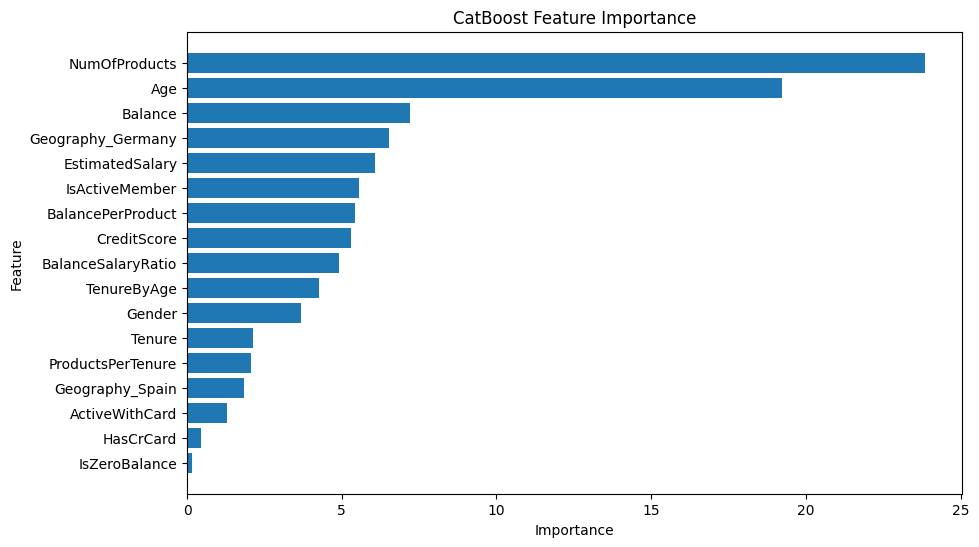

In [ ]:
# Extract feature importance from the best fitted model
feature_importance = pd.DataFrame({
    "Feature": X_train_raw.columns,
    "Importance": catboost_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

feature_importance

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

11) Final Test Evaluation

The trained CatBoost model is evaluated on the held-out test dataset.

Class predictions are used to calculate accuracy, precision, recall and F1-score. Predicted probabilities are used to calculate ROC-AUC.

These results represent the model's final performance on previously unseen data.

In [ ]:
# Generate probability predictions for the test set
test_probabilities = catboost_model.predict_proba(X_test)[:, 1]

# Convert probabilities into class predictions using the default 0.5 threshold
test_predictions = (test_probabilities >= 0.5).astype(int)

# Calculate test set metrics
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)
test_auc = roc_auc_score(y_test, test_probabilities)

print("Test Set Results")
print("================")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")

Test Set Results
Accuracy  : 0.8218
Precision : 0.5372
Recall    : 0.7063
F1 Score  : 0.6103
ROC-AUC   : 0.8617


12) Confusion Matrix and Classification Report

The confusion matrix shows the numbers of true positives, true negatives, false positives and false negatives.

The classification report provides precision, recall and F1-score for each class, allowing the model's churn classification performance to be examined in more detail.

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, test_predictions)

print("Confusion Matrix")
print("================")
print(cm)

print("\nClassification Report")
print("=====================")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Retained", "Churned"]
    )
)

Confusion Matrix
[[1306  230]
 [ 111  267]]

Classification Report
              precision    recall  f1-score   support

    Retained       0.92      0.85      0.88      1536
     Churned       0.54      0.71      0.61       378

    accuracy                           0.82      1914
   macro avg       0.73      0.78      0.75      1914
weighted avg       0.85      0.82      0.83      1914



13) ROC Curve

The ROC curve illustrates the relationship between the true positive rate and false positive rate across different classification thresholds.

The area under the ROC curve (ROC-AUC) provides a threshold-independent measure of the model's ability to distinguish between churned and non-churned customers.

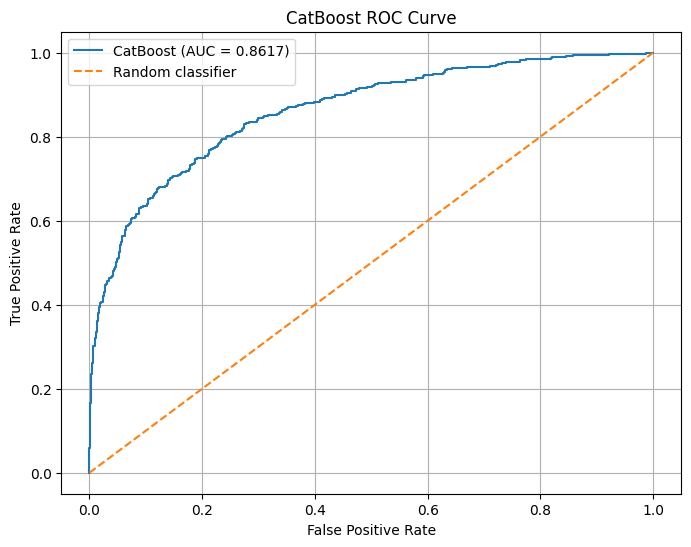

In [ ]:
# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_probabilities
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CatBoost (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

14) Final Model Summary

The final section summarises the performance of the new CatBoost model.

The 5-fold cross-validation results describe performance across the training data, while the test results describe performance on the separate held-out test set.

The results should be interpreted independently from the previous CatBoost model because the new model was trained using a different processed feature representation.

In [ ]:
# Create a summary of model performance
results_summary = pd.DataFrame({
    "Evaluation": [
        "5-Fold Cross-Validation",
        "Held-Out Test Set"
    ],
    "F1 Score": [
        cv_f1,
        test_f1
    ],
    "ROC-AUC": [
        cv_auc,
        test_auc
    ]
})

results_summary

,Evaluation,F1 Score,ROC-AUC
0,5-Fold Cross-Validation,0.592526,0.846213
1,Held-Out Test Set,0.610286,0.861690
